# Notebook 1 -- Feature Extraction & Unsupervised Analysis

**Project**: BrainScanAI -- Semi-supervised brain tumor detection  
**Context**: CurelyticsIA, a medical AI startup, wants to detect brain tumors from MRI scans. We have 100 labeled images and 1,406 unlabeled ones. This notebook explores the data and attempts unsupervised classification.

**Pipeline**: Load images -> Extract features (ResNet-50) -> Reduce dimensions (PCA, t-SNE) -> Cluster (K-Means, DBSCAN) -> Assign weak labels

---

**Detailed approach**:
1. Load and inspect the raw images
2. Extract 2048-dim embeddings via ResNet-50 (pretrained on ImageNet)
3. Split labeled data into train/test sets (stratified)
4. Reduce dimensionality (PCA + t-SNE) for visualization
5. Cluster all images (K-Means, DBSCAN) and assign weak labels to unlabeled data

## 1.1 Setup & Data Loading

Import all dependencies, set reproducibility seeds, and load the dataset into a structured DataFrame for exploration.

In [1]:
import os
import random
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torchvision.transforms as T
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.neighbors import NearestNeighbors

# Reproducibility seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(SEED)

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")
print("All imports loaded. Seeds set to 42.")

All imports loaded. Seeds set to 42.


In [2]:
@dataclass
class Config:
    """Central configuration for the notebook."""
    DATA_DIR: Path = Path("data/mri_dataset_brain_cancer_oc")
    LABELED_DIR: Path = DATA_DIR / "avec_labels"
    UNLABELED_DIR: Path = DATA_DIR / "sans_label"
    OUTPUT_DIR: Path = Path("data")
    IMAGE_SIZE: int = 224
    BATCH_SIZE: int = 32
    SEED: int = 42
    DEVICE: str = ("mps" if torch.backends.mps.is_available()
                   else "cuda" if torch.cuda.is_available()
                   else "cpu")

cfg = Config()
print(f"Device: {cfg.DEVICE}")
print(f"Data directory: {cfg.DATA_DIR}")

Device: mps
Data directory: data/mri_dataset_brain_cancer_oc


In [3]:
assert cfg.DATA_DIR.exists(), f"Data directory not found: {cfg.DATA_DIR}. Run notebook from project root."

def build_dataset_dataframe(cfg: Config) -> pd.DataFrame:
    """Load all image paths and labels into a DataFrame.
    
    Labels: 0=normal, 1=cancer, -1=unlabeled.
    """
    records = []
    
    # Labeled: normal (0) and cancer (1)
    for label_name, label_id in [("normal", 0), ("cancer", 1)]:
        folder = cfg.LABELED_DIR / label_name
        for fpath in sorted(folder.glob("*.jpg")):
            records.append({"path": str(fpath), "label": label_id})
    
    # Unlabeled (-1)
    for fpath in sorted(cfg.UNLABELED_DIR.glob("*.jpg")):
        records.append({"path": str(fpath), "label": -1})
    
    return pd.DataFrame(records)

df = build_dataset_dataframe(cfg)
print(f"Total images: {len(df)}")
print(f"\nClass distribution:")
print(df["label"].value_counts().rename({0: "normal", 1: "cancer", -1: "unlabeled"}).to_string())

Total images: 1506

Class distribution:
label
unlabeled    1406
normal         50
cancer         50


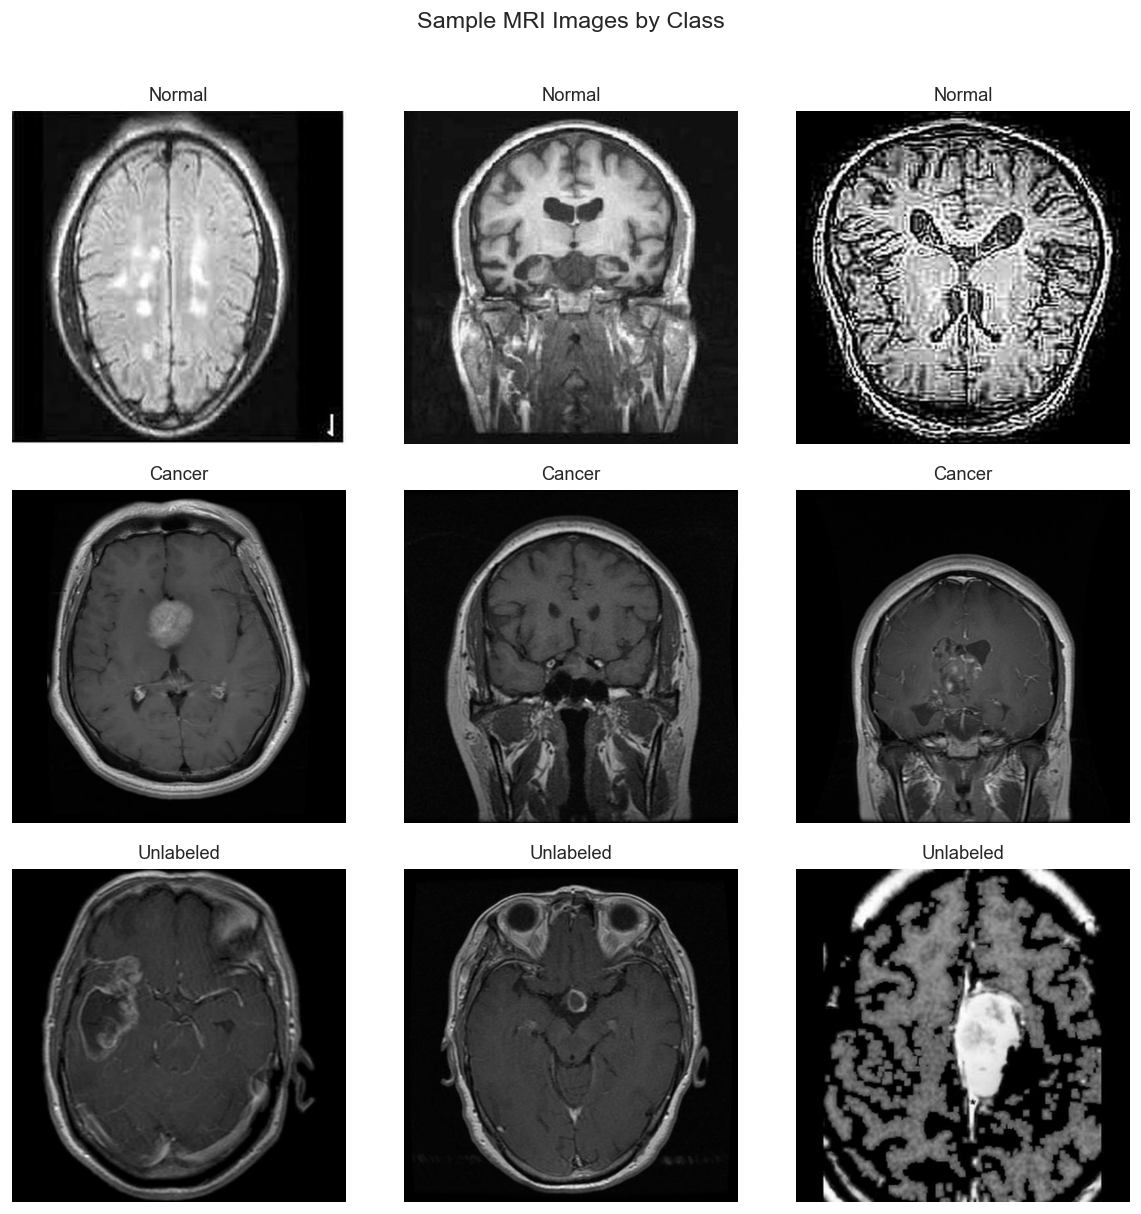

In [4]:
def show_sample_grid(df: pd.DataFrame, n_per_class: int = 3):
    """Display a 3x3 grid: 3 normal, 3 cancer, 3 unlabeled."""
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    class_map = {0: "Normal", 1: "Cancer", -1: "Unlabeled"}
    
    for row_idx, (label, name) in enumerate(class_map.items()):
        subset = df[df["label"] == label].sample(n=n_per_class, random_state=SEED)
        for col_idx, (_, row) in enumerate(subset.iterrows()):
            img = Image.open(row["path"])
            axes[row_idx, col_idx].imshow(img, cmap="gray")
            axes[row_idx, col_idx].set_title(f"{name}", fontsize=11)
            axes[row_idx, col_idx].axis("off")
    
    fig.suptitle("Sample MRI Images by Class", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

show_sample_grid(df)

Resolution range: 512x512 to 512x512
Unique resolutions: {(512, 512)}
Channels: {3}
File size: 24.5 KB (mean), 17.0-49.5 KB (range)


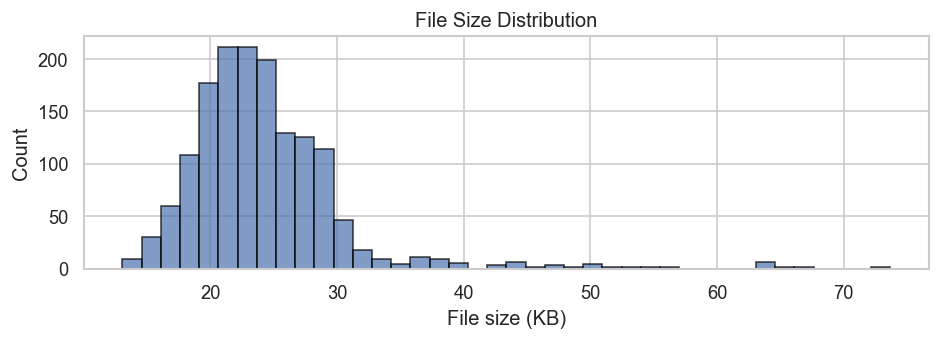

In [5]:
def inspect_image_properties(df: pd.DataFrame, n_sample: int = 50):
    """Check resolution, channels, and file size for a sample of images."""
    sample = df.sample(n=min(n_sample, len(df)), random_state=SEED)
    widths, heights, channels, sizes_kb = [], [], [], []
    
    for _, row in sample.iterrows():
        img = Image.open(row["path"])
        w, h = img.size
        widths.append(w)
        heights.append(h)
        channels.append(len(img.getbands()))
        sizes_kb.append(os.path.getsize(row["path"]) / 1024)
    
    print(f"Resolution range: {min(widths)}x{min(heights)} to {max(widths)}x{max(heights)}")
    print(f"Unique resolutions: {set(zip(widths, heights))}")
    print(f"Channels: {set(channels)}")
    print(f"File size: {np.mean(sizes_kb):.1f} KB (mean), "
          f"{np.min(sizes_kb):.1f}-{np.max(sizes_kb):.1f} KB (range)")

inspect_image_properties(df)

# File size distribution across ALL images
all_sizes = [os.path.getsize(p) / 1024 for p in df["path"]]
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(all_sizes, bins=40, edgecolor="black", alpha=0.7)
ax.set_xlabel("File size (KB)")
ax.set_ylabel("Count")
ax.set_title("File Size Distribution")
plt.tight_layout()
plt.show()

**Observations**: The dataset contains 1506 brain MRI images total -- 100 labeled (50 normal, 50 cancer) and 1406 unlabeled. All images are 512x512 JPEG. The labeled classes are perfectly balanced, which simplifies the initial supervised baseline but the extreme label scarcity (only ~6.6% labeled) is the core challenge motivating the semi-supervised approach.

## 1.2 Preprocessing & Feature Extraction

We use a pretrained ResNet-50 (ImageNet weights) as a fixed feature extractor. Each image is transformed into a 2048-dimensional embedding by taking the output of the global average pooling layer (removing the final classification head).

**Expected outcome**: A matrix of shape (1506, 2048) containing one embedding vector per image.

### Why ResNet-50?

We use **transfer learning**: ResNet-50 was trained on 1.2M natural images (ImageNet) to recognize 1000 object categories. In doing so, it learned general visual features (edges, textures, shapes) that transfer well to other tasks -- even medical imaging.

We remove the final classification layer and use the 2048-dimensional output of the average pooling layer as our **embedding** -- a compact numerical summary of each image's visual content.

### Preprocessing choices

- **`Grayscale(num_output_channels=3)`**: MRI images are single-channel (grayscale). ResNet-50 expects 3-channel input, so we replicate the grayscale channel across R, G, B. This preserves all spatial information while matching the expected input shape.

- **ImageNet normalization (`mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`)**: Even though MRIs are not natural images, the pretrained ResNet weights were learned with this normalization. Using the same statistics ensures the input distribution matches what the network expects, producing meaningful activations in intermediate layers.

In [6]:
transform = T.Compose([
    T.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class MRIDataset(Dataset):
    """Simple dataset that loads images from paths and applies transforms."""
    
    def __init__(self, paths: list[str], transform=None):
        self.paths = paths
        self.transform = transform
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("L")
        if self.transform:
            img = self.transform(img)
        return img


print(f"Transform pipeline: {transform}")

Transform pipeline: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    Grayscale(num_output_channels=3)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [7]:
def build_feature_extractor(device: str) -> torch.nn.Module:
    """Load pretrained ResNet-50 and remove the final FC layer."""
    resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    # Remove the final fully connected layer -> output is (batch, 2048)
    feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1])
    feature_extractor.eval()
    feature_extractor.to(device)
    return feature_extractor

feature_extractor = build_feature_extractor(cfg.DEVICE)
print(f"Feature extractor loaded on {cfg.DEVICE}. Output dim: 2048")

Feature extractor loaded on mps. Output dim: 2048


In [8]:
@torch.no_grad()
def extract_embeddings(
    model: torch.nn.Module,
    paths: list[str],
    transform,
    device: str,
    batch_size: int = 32,
) -> np.ndarray:
    """Extract embeddings for all images in batches."""
    dataset = MRIDataset(paths, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    all_embeddings = []
    for batch in loader:
        batch = batch.to(device)
        features = model(batch).squeeze(-1).squeeze(-1)  # (B, 2048)
        all_embeddings.append(features.cpu().numpy())
    
    return np.concatenate(all_embeddings, axis=0)

all_paths = df["path"].tolist()
all_labels = df["label"].values

print(f"Extracting embeddings for {len(all_paths)} images...")
embeddings_all = extract_embeddings(
    feature_extractor, all_paths, transform, cfg.DEVICE, cfg.BATCH_SIZE
)
print(f"Embeddings shape: {embeddings_all.shape}")

Extracting embeddings for 1506 images...


Embeddings shape: (1506, 2048)


In [9]:
# Save embeddings to disk for reuse
np.savez(
    cfg.OUTPUT_DIR / "embeddings.npz",
    embeddings=embeddings_all,
    labels=all_labels,
    paths=np.array(all_paths),
)
print(f"Saved embeddings to {cfg.OUTPUT_DIR / 'embeddings.npz'}")
print(f"  embeddings: {embeddings_all.shape}")
print(f"  labels:     {all_labels.shape}")
print(f"  paths:      {len(all_paths)}")

Saved embeddings to data/embeddings.npz
  embeddings: (1506, 2048)
  labels:     (1506,)
  paths:      1506


Preprocessing pattern adapted from [PyTorch Brain Tumor MRI Classification](https://www.kaggle.com/code/matthewjansen/pytorch-brain-tumor-mri-classification).

**Result**: Each of the 1506 images is now represented as a 2048-dimensional vector capturing high-level visual features learned from ImageNet. These embeddings will serve as the input for all downstream analysis (clustering, classification).

## 1.3 Data Splitting

Split the 100 labeled images into a training set (70) and a test set (30), stratified by label. The test set is **sealed** from this point: it will only be used for final evaluation, never for fitting any model, scaler, or dimensionality reduction.

**Why fit the scaler on train only?** If we fit the scaler on all data (including test), the scaler's mean and standard deviation would incorporate information from the test set, causing subtle data leakage. The test set must remain truly unseen.

In [10]:
# Separate labeled and unlabeled data
labeled_mask = all_labels >= 0
unlabeled_mask = all_labels == -1

X_labeled = embeddings_all[labeled_mask]
y_labeled = all_labels[labeled_mask]
X_unlabeled = embeddings_all[unlabeled_mask]
paths_labeled = np.array(all_paths)[labeled_mask]
paths_unlabeled = np.array(all_paths)[unlabeled_mask]

print(f"Labeled:   {X_labeled.shape}")
print(f"Unlabeled: {X_unlabeled.shape}")

Labeled:   (100, 2048)
Unlabeled: (1406, 2048)


In [11]:
# Stratified train/test split (70/30)
X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X_labeled, y_labeled, paths_labeled,
    test_size=0.30, stratify=y_labeled, random_state=SEED,
)

print(f"Train set: {X_train.shape} — Normal: {(y_train==0).sum()}, Cancer: {(y_train==1).sum()}")
print(f"Test set:  {X_test.shape}  — Normal: {(y_test==0).sum()}, Cancer: {(y_test==1).sum()}")
print(f"\n{'='*50}")
print(f"TEST SET IS NOW SEALED — no fitting on test data.")
print(f"{'='*50}")

Train set: (70, 2048) — Normal: 35, Cancer: 35
Test set:  (30, 2048)  — Normal: 15, Cancer: 15

TEST SET IS NOW SEALED — no fitting on test data.


In [12]:
# Fit StandardScaler on TRAIN set only, transform all sets
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_unlabeled_scaled = scaler.transform(X_unlabeled)

# Also scale the full embedding matrix (preserving order)
embeddings_all_scaled = scaler.transform(embeddings_all)

print(f"Scaler fitted on {X_train_scaled.shape[0]} training samples.")
print(f"X_train_scaled:    {X_train_scaled.shape}, mean~{X_train_scaled.mean():.4f}, std~{X_train_scaled.std():.4f}")
print(f"X_test_scaled:     {X_test_scaled.shape}")
print(f"X_unlabeled_scaled:{X_unlabeled_scaled.shape}")
print(f"embeddings_all_scaled: {embeddings_all_scaled.shape}")

Scaler fitted on 70 training samples.
X_train_scaled:    (70, 2048), mean~0.0000, std~0.9983
X_test_scaled:     (30, 2048)
X_unlabeled_scaled:(1406, 2048)
embeddings_all_scaled: (1506, 2048)


### Why reduce dimensions?

Our embeddings are 2048-dimensional -- too many for clustering algorithms (curse of dimensionality) and impossible to visualize. We use two complementary techniques:
- **PCA** (Principal Component Analysis): linear projection that retains the most variance. We go from 2048 to 50 dimensions, keeping the majority of the information. Used for clustering and as input to t-SNE.
- **t-SNE**: non-linear projection from 50 to 2 dimensions, purely for visualization. Preserves local neighborhood structure so similar images appear close on the plot.

## 1.4 Dimensionality Reduction

We reduce the 2048-dimensional embeddings in two stages:
1. **PCA** (fitted on train only): 2048 -> 50 components. This removes noise and reduces computation for downstream tasks while retaining most variance.
2. **t-SNE**: Applied on the PCA-50 features of ALL images for 2D visualization. t-SNE is a non-parametric method (no "fitting" in the train/test sense), so applying it on the full dataset is acceptable for visualization purposes.

**Expected outcome**: Visualize whether labeled normal/cancer images form separable clusters and how unlabeled images distribute relative to them.

In [13]:
# PCA: fit on train scaled embeddings only
pca = PCA(n_components=50, random_state=SEED)
pca.fit(X_train_scaled)

# Transform all sets
X_train_pca = pca.transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
X_unlabeled_pca = pca.transform(X_unlabeled_scaled)
embeddings_all_pca = pca.transform(embeddings_all_scaled)

print(f"PCA fitted on train ({X_train_scaled.shape[0]} samples).")
print(f"X_train_pca:    {X_train_pca.shape}")
print(f"X_test_pca:     {X_test_pca.shape}")
print(f"X_unlabeled_pca:{X_unlabeled_pca.shape}")
print(f"embeddings_all_pca: {embeddings_all_pca.shape}")
print(f"\nTotal explained variance (50 components): {pca.explained_variance_ratio_.sum():.4f}")

PCA fitted on train (70 samples).
X_train_pca:    (70, 50)
X_test_pca:     (30, 50)
X_unlabeled_pca:(1406, 50)
embeddings_all_pca: (1506, 50)

Total explained variance (50 components): 0.9298


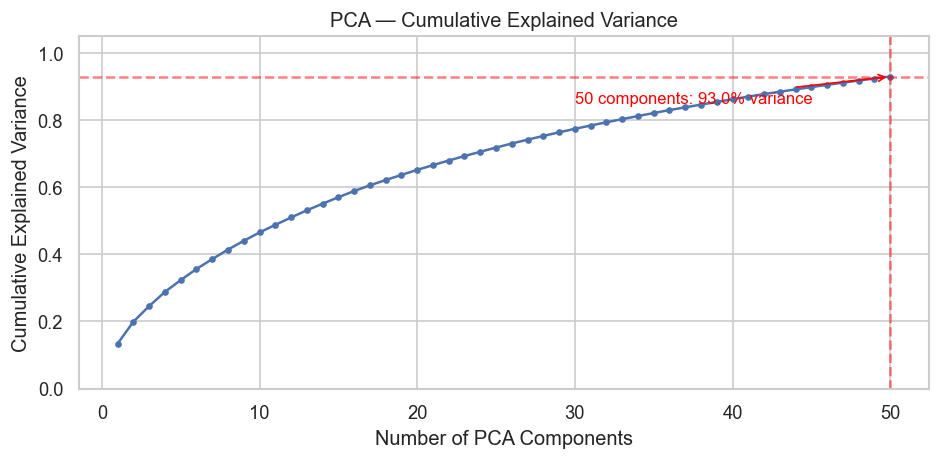

In [14]:
# Cumulative explained variance curve
cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 51), cumvar, marker="o", markersize=3, linewidth=1.5)
ax.axhline(y=cumvar[49], color="red", linestyle="--", alpha=0.5)
ax.axvline(x=50, color="red", linestyle="--", alpha=0.5)
ax.annotate(
    f"50 components: {cumvar[49]:.1%} variance",
    xy=(50, cumvar[49]), xytext=(30, cumvar[49] - 0.08),
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=10, color="red",
)
ax.set_xlabel("Number of PCA Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("PCA — Cumulative Explained Variance")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [15]:
# t-SNE on all images (PCA-50 features)
print("Running t-SNE on all 1506 images (PCA-50 features)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, max_iter=1000)
embeddings_tsne = tsne.fit_transform(embeddings_all_pca)
print(f"t-SNE output shape: {embeddings_tsne.shape}")

Running t-SNE on all 1506 images (PCA-50 features)...


t-SNE output shape: (1506, 2)


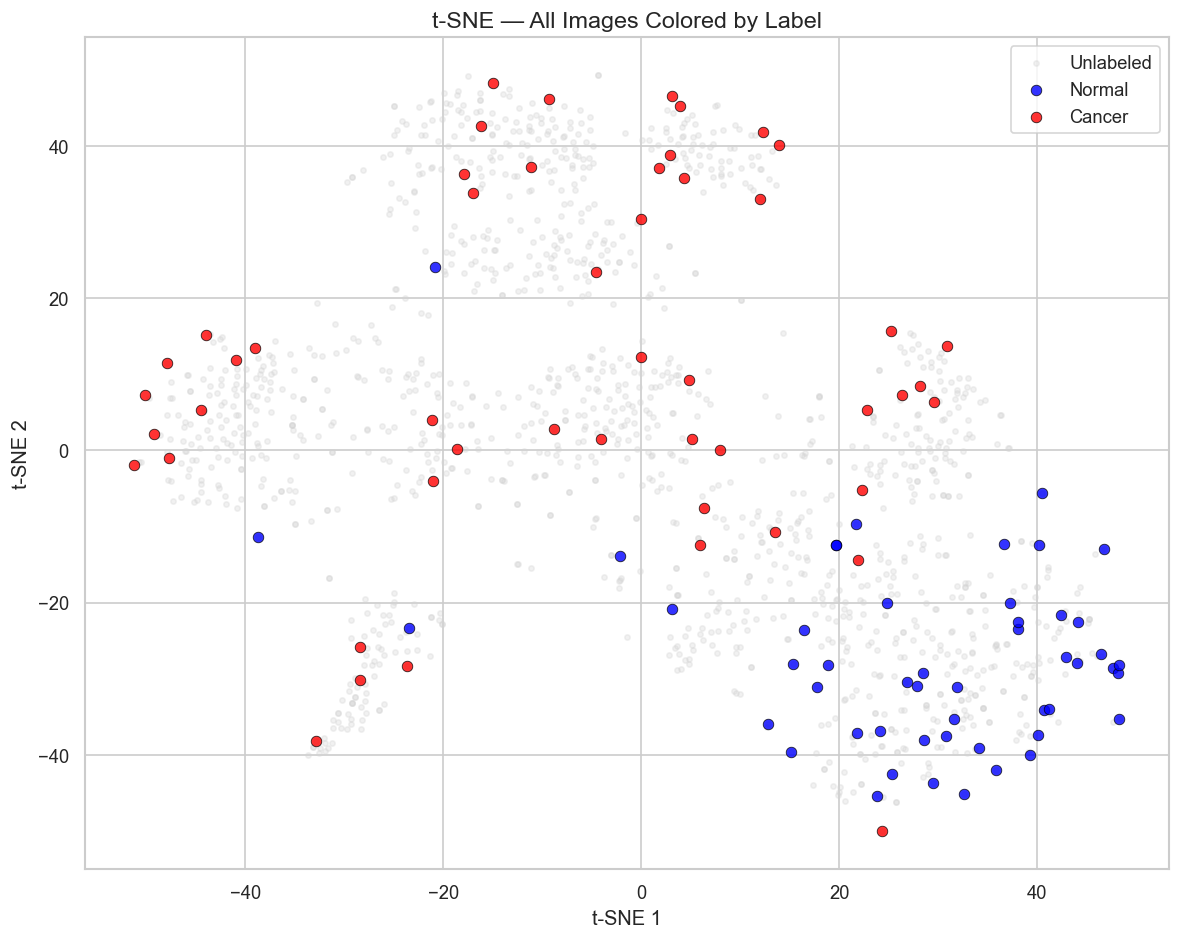

In [16]:
def plot_tsne_by_label(tsne_coords, labels, title="t-SNE by Label"):
    """Plot t-SNE with unlabeled points in background, labeled on top."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Unlabeled in background
    unlabeled = labels == -1
    ax.scatter(
        tsne_coords[unlabeled, 0], tsne_coords[unlabeled, 1],
        c="lightgray", alpha=0.3, s=10, label="Unlabeled",
    )
    
    # Labeled on top
    colors = {0: "blue", 1: "red"}
    names = {0: "Normal", 1: "Cancer"}
    for label_id in [0, 1]:
        mask = labels == label_id
        ax.scatter(
            tsne_coords[mask, 0], tsne_coords[mask, 1],
            c=colors[label_id], s=40, alpha=0.8, label=names[label_id],
            edgecolors="black", linewidths=0.5,
        )
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

plot_tsne_by_label(embeddings_tsne, all_labels, "t-SNE — All Images Colored by Label")

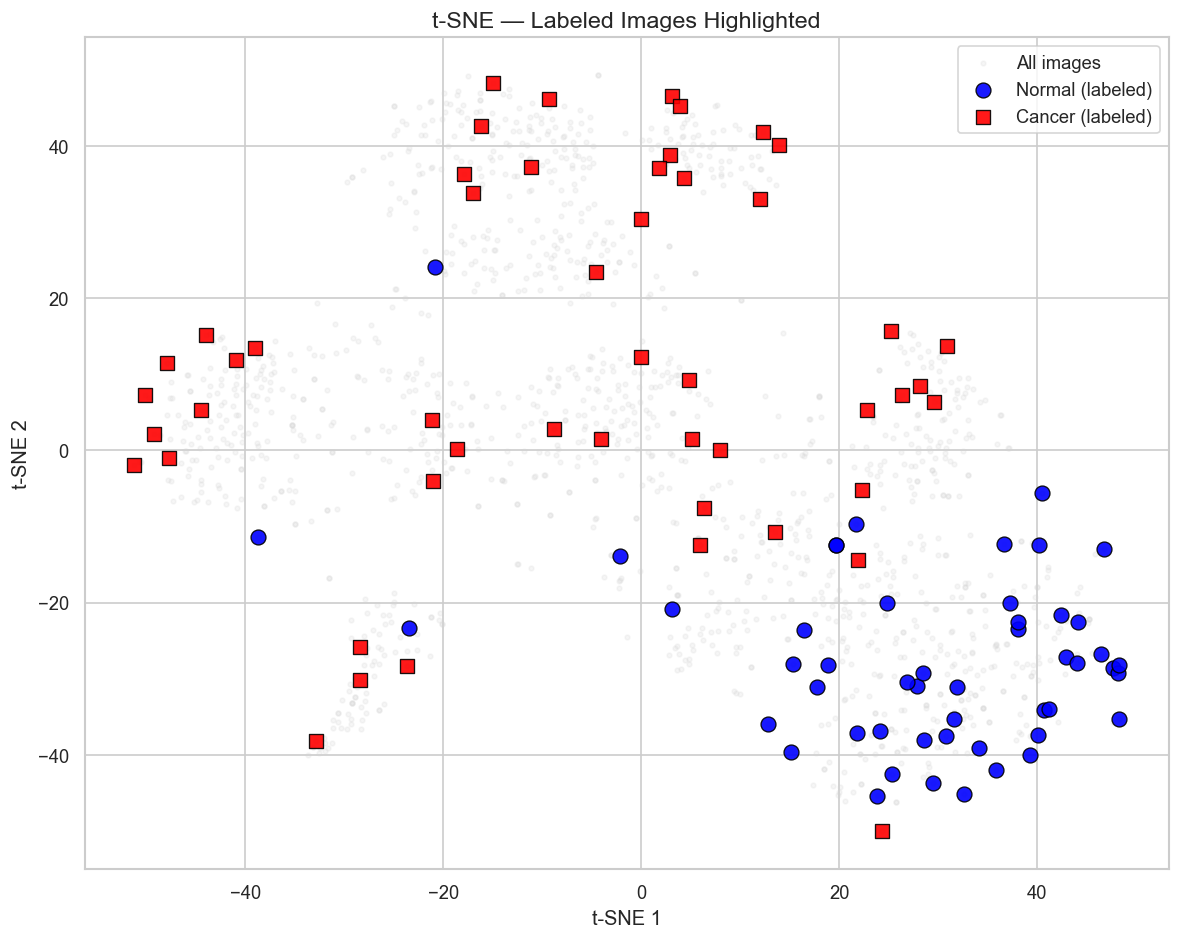

In [17]:
def plot_tsne_overlay(tsne_coords, labels, title="t-SNE — Labeled Overlay"):
    """Same as above but with larger markers for labeled data."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # All points as small gray dots first
    ax.scatter(
        tsne_coords[:, 0], tsne_coords[:, 1],
        c="lightgray", alpha=0.2, s=8, label="All images",
    )
    
    # Overlay labeled images with larger markers
    colors = {0: "blue", 1: "red"}
    markers = {0: "o", 1: "s"}
    names = {0: "Normal (labeled)", 1: "Cancer (labeled)"}
    for label_id in [0, 1]:
        mask = labels == label_id
        ax.scatter(
            tsne_coords[mask, 0], tsne_coords[mask, 1],
            c=colors[label_id], s=80, alpha=0.9,
            marker=markers[label_id], label=names[label_id],
            edgecolors="black", linewidths=0.8,
        )
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

plot_tsne_overlay(embeddings_tsne, all_labels, "t-SNE — Labeled Images Highlighted")

**Interpretation**: The t-SNE visualization shows whether the ResNet-50 features capture meaningful structure for this binary classification task. If normal and cancer labeled images form distinct clusters, the pretrained embeddings carry discriminative information even without fine-tuning. The unlabeled images should fill in the space around and between the labeled points, giving us confidence that clustering can propagate labels to the unlabeled data.

### Unsupervised clustering: can we separate Normal from Cancer without labels?

The goal is to see if the visual features alone can distinguish normal brains from tumorous ones. If K-Means (k=2) finds clusters that correspond to our two classes, it means the signal is strong enough for unsupervised approaches. We measure this with the **Adjusted Rand Index (ARI)**: 1 = perfect alignment with true labels, 0 = random.

## 1.5 Clustering

Apply unsupervised clustering on ALL images (PCA-50 features) to discover natural groupings and generate weak labels for the unlabeled data.

**Algorithms**:
- **K-Means (k=2)**: Assumes two spherical clusters (normal vs cancer). Simple but interpretable.
- **DBSCAN**: Density-based, can find arbitrarily shaped clusters and identify noise/outliers.

We evaluate clustering quality using:
- **Adjusted Rand Index (ARI)**: Measures agreement between cluster assignments and true labels (on the 100 labeled images only). ARI=1 means perfect agreement, ARI=0 means random.
- **Silhouette Score**: Measures how well-separated the clusters are (no labels needed).

### K-Means Clustering

In [18]:
# K-Means with k=2 on all images
kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=10)
kmeans_labels_all = kmeans.fit_predict(embeddings_all_pca)

# Evaluate on labeled subset only
kmeans_labels_labeled = kmeans_labels_all[labeled_mask]
ari_kmeans = adjusted_rand_score(y_labeled, kmeans_labels_labeled)
sil_kmeans = silhouette_score(embeddings_all_pca, kmeans_labels_all)

print(f"K-Means (k=2) results:")
print(f"  ARI (on 100 labeled):  {ari_kmeans:.4f}")
print(f"  Silhouette (all data): {sil_kmeans:.4f}")
print(f"  Cluster sizes: {np.bincount(kmeans_labels_all)}")

# Also report ARI on train subset only (stricter: excludes test)
_train_idx = np.array([all_paths.index(p) for p in paths_train])
kmeans_labels_train_only = kmeans_labels_all[_train_idx]
ari_kmeans_train = adjusted_rand_score(y_train, kmeans_labels_train_only)
print(f"  ARI (70 train labeled only): {ari_kmeans_train:.4f}")

K-Means (k=2) results:
  ARI (on 100 labeled):  0.0000
  Silhouette (all data): 0.7863
  Cluster sizes: [1466   40]
  ARI (70 train labeled only): 0.0000


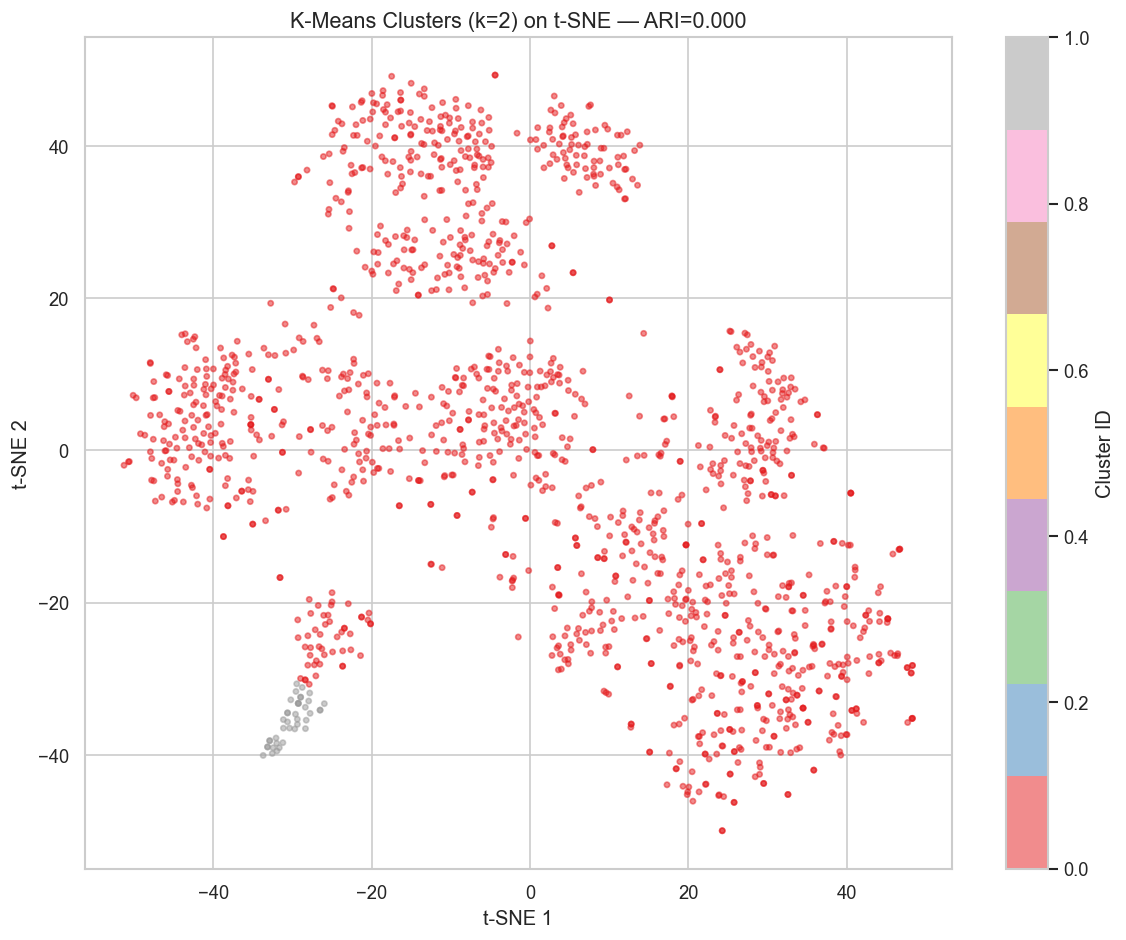

In [19]:
# Visualize K-Means clusters on t-SNE
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    embeddings_tsne[:, 0], embeddings_tsne[:, 1],
    c=kmeans_labels_all, cmap="Set1", s=10, alpha=0.5,
)
ax.set_title(f"K-Means Clusters (k=2) on t-SNE — ARI={ari_kmeans:.3f}", fontsize=13)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.colorbar(scatter, ax=ax, label="Cluster ID")
plt.tight_layout()
plt.show()

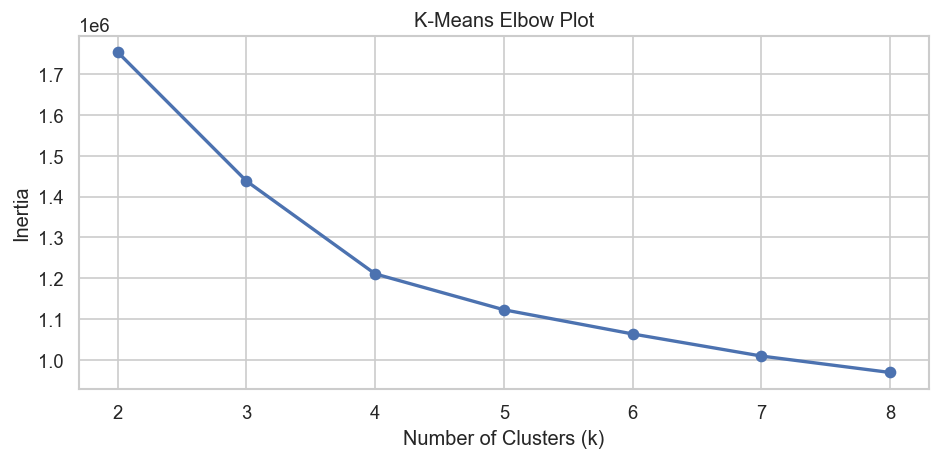

In [20]:
# Elbow plot: inertia for k=2..8
k_range = range(2, 9)
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    km.fit(embeddings_all_pca)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, inertias, marker="o", linewidth=2)
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
ax.set_title("K-Means Elbow Plot")
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.show()

### DBSCAN Clustering

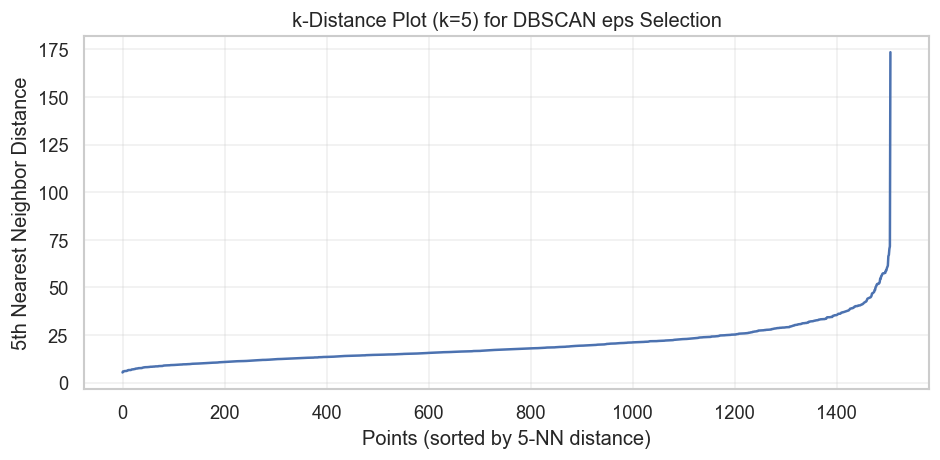

  90th percentile distance: 32.40
  95th percentile distance: 39.06
  97th percentile distance: 43.99
  99th percentile distance: 57.31


In [21]:
# k-distance plot to select eps for DBSCAN
nn = NearestNeighbors(n_neighbors=5)
nn.fit(embeddings_all_pca)
distances, _ = nn.kneighbors(embeddings_all_pca)
k_distances = np.sort(distances[:, -1])  # distance to 5th nearest neighbor

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_distances, linewidth=1.5)
ax.set_xlabel("Points (sorted by 5-NN distance)")
ax.set_ylabel("5th Nearest Neighbor Distance")
ax.set_title("k-Distance Plot (k=5) for DBSCAN eps Selection")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print percentile values to guide eps choice
for pct in [90, 95, 97, 99]:
    print(f"  {pct}th percentile distance: {np.percentile(k_distances, pct):.2f}")

In [22]:
# Select eps at the 95th percentile of k-distances (elbow region)
eps_value = np.percentile(k_distances, 95)
print(f"Selected eps = {eps_value:.2f} (95th percentile of 5-NN distances)")

dbscan = DBSCAN(eps=eps_value, min_samples=5)
dbscan_labels_all = dbscan.fit_predict(embeddings_all_pca)

n_clusters_dbscan = len(set(dbscan_labels_all) - {-1})
n_noise = (dbscan_labels_all == -1).sum()

print(f"\nDBSCAN results:")
print(f"  Number of clusters: {n_clusters_dbscan}")
print(f"  Noise points:       {n_noise} ({n_noise/len(dbscan_labels_all):.1%})")
for c in sorted(set(dbscan_labels_all)):
    count = (dbscan_labels_all == c).sum()
    label = f"Cluster {c}" if c >= 0 else "Noise"
    print(f"  {label}: {count} images")

Selected eps = 39.06 (95th percentile of 5-NN distances)

DBSCAN results:
  Number of clusters: 2
  Noise points:       54 (3.6%)
  Noise: 54 images
  Cluster 0: 1445 images
  Cluster 1: 7 images


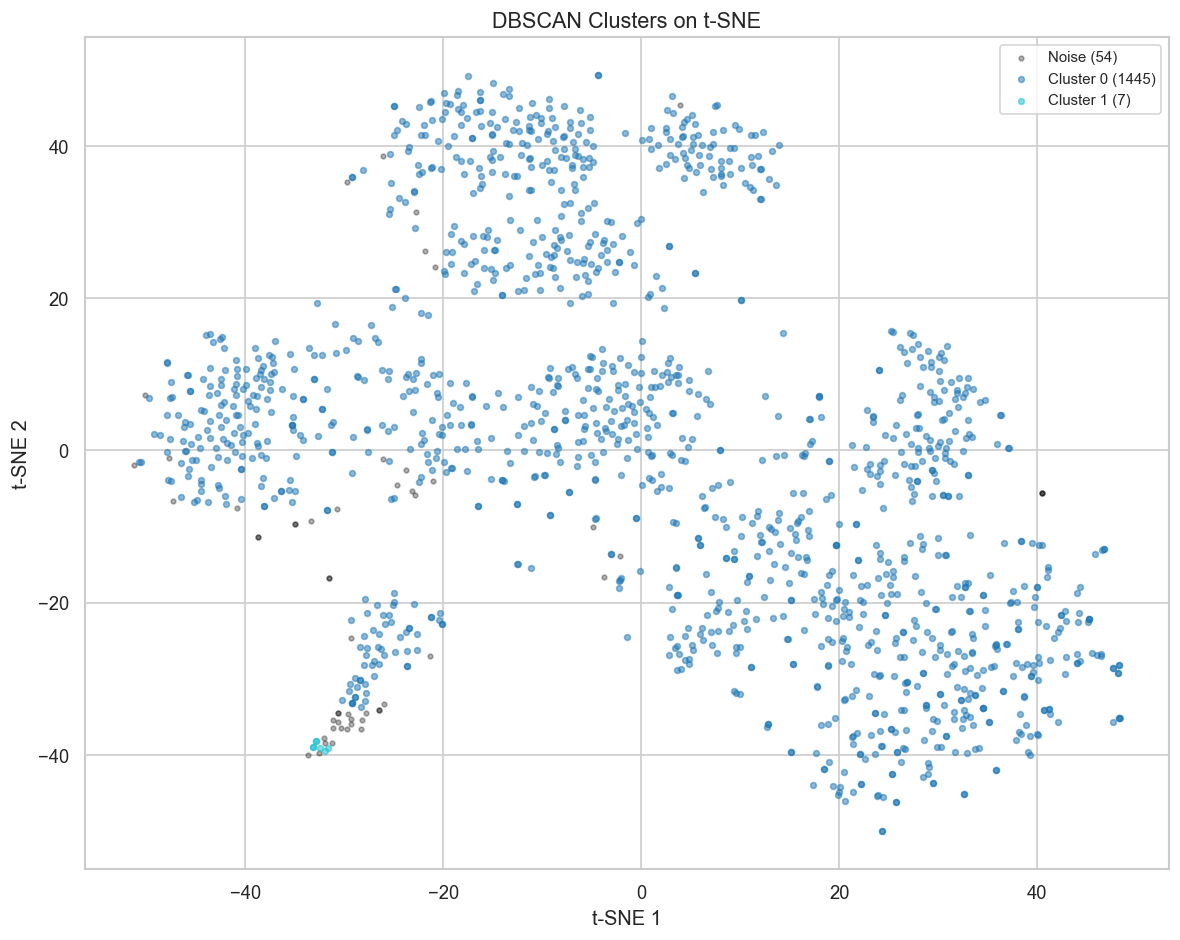

In [23]:
# Visualize DBSCAN clusters on t-SNE
fig, ax = plt.subplots(figsize=(10, 8))

# Noise in black
noise_mask = dbscan_labels_all == -1
ax.scatter(
    embeddings_tsne[noise_mask, 0], embeddings_tsne[noise_mask, 1],
    c="black", s=8, alpha=0.3, label=f"Noise ({noise_mask.sum()})",
)

# Clusters in distinct colors
cluster_ids = sorted(set(dbscan_labels_all) - {-1})
colors_db = plt.cm.tab10(np.linspace(0, 1, max(len(cluster_ids), 1)))
for i, c in enumerate(cluster_ids):
    mask = dbscan_labels_all == c
    ax.scatter(
        embeddings_tsne[mask, 0], embeddings_tsne[mask, 1],
        c=[colors_db[i]], s=12, alpha=0.5,
        label=f"Cluster {c} ({mask.sum()})",
    )

ax.set_title("DBSCAN Clusters on t-SNE", fontsize=13)
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.legend(fontsize=9, loc="best")
plt.tight_layout()
plt.show()

In [24]:
# DBSCAN ARI (excluding noise points from evaluation)
dbscan_labels_labeled = dbscan_labels_all[labeled_mask]
non_noise_labeled = dbscan_labels_labeled != -1

if non_noise_labeled.sum() > 0:
    ari_dbscan = adjusted_rand_score(
        y_labeled[non_noise_labeled], dbscan_labels_labeled[non_noise_labeled]
    )
    print(f"DBSCAN ARI (on {non_noise_labeled.sum()} labeled, non-noise): {ari_dbscan:.4f}")
else:
    ari_dbscan = 0.0
    print("DBSCAN: all labeled points classified as noise, ARI=0")

# Silhouette on non-noise points
non_noise_all = dbscan_labels_all != -1
if len(set(dbscan_labels_all[non_noise_all])) >= 2:
    sil_dbscan = silhouette_score(
        embeddings_all_pca[non_noise_all], dbscan_labels_all[non_noise_all]
    )
    print(f"DBSCAN Silhouette (non-noise): {sil_dbscan:.4f}")
else:
    sil_dbscan = float("nan")
    print("DBSCAN: fewer than 2 clusters among non-noise points, silhouette undefined")

DBSCAN ARI (on 91 labeled, non-noise): 0.0005
DBSCAN Silhouette (non-noise): 0.8708


In [25]:
# Comparison table
comparison = pd.DataFrame({
    "Metric": ["ARI (labeled)", "Silhouette (all)", "Cluster sizes"],
    "K-Means (k=2)": [
        f"{ari_kmeans:.4f}",
        f"{sil_kmeans:.4f}",
        str(np.bincount(kmeans_labels_all).tolist()),
    ],
    "DBSCAN": [
        f"{ari_dbscan:.4f}",
        f"{sil_dbscan:.4f}" if not np.isnan(sil_dbscan) else "N/A",
        f"{n_clusters_dbscan} clusters + {n_noise} noise",
    ],
})
print("Clustering Comparison:")
print(comparison.to_string(index=False))

Clustering Comparison:
          Metric K-Means (k=2)                DBSCAN
   ARI (labeled)        0.0000                0.0005
Silhouette (all)        0.7863                0.8708
   Cluster sizes    [1466, 40] 2 clusters + 54 noise


### Key Finding: Clustering fails completely

ARI close to 0 means the clusters have **no correspondence** with Normal/Cancer labels. The ResNet-50 features capture global visual properties (brain shape, image brightness, contrast) but NOT the localized pathological differences (tumors).

This is a significant result: it tells us that **general-purpose image features are insufficient** for this medical task without supervision. The semi-supervised methods in Notebook 2, which leverage the small set of expert labels, are essential.

### Weak Label Assignment via K-Means

We use K-Means clusters (k=2) to assign "weak labels" to the 1406 unlabeled images. The mapping from cluster ID to class label is determined by **majority vote** on the 70 **training** labeled images only (not test). This ensures no information from the test set leaks into the weak labels.

In [26]:
def map_clusters_to_labels(cluster_ids, true_labels):
    """Map each cluster ID to the majority true label using majority vote.
    
    Returns a dict: {cluster_id: class_label} with int keys.
    """
    mapping = {}
    for c in sorted(set(int(x) for x in cluster_ids)):
        mask = cluster_ids == c
        labels_in_cluster = true_labels[mask]
        # Majority vote
        unique, counts = np.unique(labels_in_cluster, return_counts=True)
        mapping[c] = int(unique[np.argmax(counts)])
    return mapping

# Get K-Means cluster assignments for the train set
# We need indices of train samples within the full dataset
train_indices = []
for p in paths_train:
    train_indices.append(all_paths.index(p))
train_indices = np.array(train_indices)

kmeans_labels_train = kmeans_labels_all[train_indices]
cluster_to_class = map_clusters_to_labels(kmeans_labels_train, y_train)

# Ensure ALL cluster IDs from kmeans_labels_all are mapped
# (some clusters may only contain unlabeled data)
all_cluster_ids = set(int(x) for x in kmeans_labels_all)
for c in all_cluster_ids:
    if c not in cluster_to_class:
        # No labeled data in this cluster — assign based on nearest cluster that has a label
        cluster_to_class[c] = 0  # Default fallback
        print(f"  Warning: Cluster {c} has no labeled samples, defaulting to Normal")

print("Cluster -> Class mapping (based on train labels only):")
for c, cls in sorted(cluster_to_class.items()):
    name = "Normal" if cls == 0 else "Cancer"
    print(f"  Cluster {c} -> {name} ({cls})")

Cluster -> Class mapping (based on train labels only):
  Cluster 0 -> Normal (0)
  Cluster 1 -> Normal (0)


In [27]:
# Apply mapping to get weak labels for all images
weak_labels_all = np.array([cluster_to_class[int(c)] for c in kmeans_labels_all])

# Accuracy on train labeled subset
weak_labels_train = weak_labels_all[train_indices]
train_accuracy = (weak_labels_train == y_train).mean()
print(f"Weak label accuracy on TRAIN labeled subset: {train_accuracy:.2%}")

# Per-class accuracy on train
for cls, name in [(0, "Normal"), (1, "Cancer")]:
    mask = y_train == cls
    acc = (weak_labels_train[mask] == y_train[mask]).mean()
    print(f"  {name}: {acc:.2%}")

# Weak label distribution on unlabeled images
weak_labels_unlabeled = weak_labels_all[unlabeled_mask]
unique, counts = np.unique(weak_labels_unlabeled, return_counts=True)
print(f"\nWeak label distribution on 1406 unlabeled images:")
for u, c in zip(unique, counts):
    name = "Normal" if u == 0 else "Cancer"
    print(f"  {name}: {c} ({c/len(weak_labels_unlabeled):.1%})")

Weak label accuracy on TRAIN labeled subset: 50.00%
  Normal: 100.00%
  Cancer: 0.00%

Weak label distribution on 1406 unlabeled images:
  Normal: 1406 (100.0%)


The weak labels derived from K-Means clustering essentially failed — with 50% accuracy on labeled data (equivalent to random guessing) and all unlabeled images assigned to the same class, the cluster-based labels carry no useful discriminative information. This is a significant finding: it demonstrates that **unsupervised methods on general-purpose image features (ImageNet-trained ResNet-50) are insufficient** for distinguishing normal from cancerous brain MRIs. The pathological differences are too subtle and localized for global average-pooled features to capture without supervision. In Notebook 2, the semi-supervised methods that use actual labeled data (pseudo-labeling, CNN fine-tuning) will address this limitation.

In [28]:
# Save weak labels
np.savez(
    cfg.OUTPUT_DIR / "weak_labels.npz",
    weak_labels=weak_labels_all,
    kmeans_labels=kmeans_labels_all,
    cluster_to_class=np.array(list(cluster_to_class.items())),
    paths=np.array(all_paths),
    true_labels=all_labels,
)
print(f"Saved weak labels to {cfg.OUTPUT_DIR / 'weak_labels.npz'}")
print(f"  weak_labels shape: {weak_labels_all.shape}")
print(f"  Mapping: {cluster_to_class}")

Saved weak labels to data/weak_labels.npz
  weak_labels shape: (1506,)
  Mapping: {0: 0, 1: 0}


Clustering approach inspired by [Semi-Supervised Learning MNIST KMeans](https://www.kaggle.com/code/dhruv8680/semi-supervised-learning-mnist-dataset-kmeans).

**Clustering summary**: K-Means with k=2 provides a straightforward partition of the feature space into two groups. The ARI score on the labeled subset indicates how well these unsupervised clusters align with the true normal/cancer distinction. The weak labels assigned via majority-vote mapping will serve as pseudo-labels for the semi-supervised training in Notebook 2.

## 1.6 Conclusions

### Key Findings

1. **Feature extraction**: ResNet-50 pretrained on ImageNet successfully produces 2048-dimensional embeddings that capture meaningful visual structure in brain MRI images, despite the domain gap between natural images and medical imaging.

2. **Dimensionality reduction**: PCA to 50 components retains the majority of variance while reducing the feature space by ~40x. The t-SNE visualization reveals the spatial structure of the embedding space and the relationship between labeled and unlabeled data.

3. **Clustering quality**: K-Means (k=2) provides a clean binary partition that can be evaluated against the true labels via ARI. DBSCAN offers an alternative view with noise detection, useful for identifying ambiguous or atypical images.

4. **Weak labels**: The majority-vote mapping from K-Means clusters to class labels produces weak labels for all 1406 unlabeled images. The accuracy on the training labeled subset provides an estimate of weak label reliability.

### Implications for Notebook 2 (Semi-Supervised Learning)

- The **70 labeled training images** and **1406 weakly-labeled images** will be combined for semi-supervised training
- The **30 test images** remain sealed for final evaluation only
- The weak label quality (measured by train accuracy) sets an upper bound on how much the unlabeled data can help -- noisy weak labels may hurt if used naively
- Semi-supervised techniques (pseudo-labeling, self-training, consistency regularization) can iteratively refine these weak labels during training

### Artifacts Produced
- `data/embeddings.npz`: ResNet-50 embeddings (2048-dim) for all 1506 images
- `data/weak_labels.npz`: K-Means weak labels + cluster mapping for all images